In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Utilities import extractor
import uproot
import awkward as ak    

x_MH100=extractor("Dati/Tprime_tAq_1800_MH100_LH_2017.root", "Events")


file=uproot.open("Dati/Tprime_tAq_1800_MH100_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]

#Filtriamo i dati

mask = ak.flatten(Fatjet_isMatchedWithA) == 1
x_filtered = x_MH100[mask]


/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/riccardo/anaconda3/envs/rootnev/include/site/python3.14); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "
/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


In [2]:
from scipy.special import voigt_profile
from iminuit import Minuit
from iminuit.cost import LeastSquares

x_plot=list(x_filtered)
x_plot.sort()

def voigt(x, norm, mu, sigma, gamma):
    return voigt_profile(x-mu, sigma, gamma) * norm

bin_counts, bin_edges = np.histogram(x_plot, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_plot) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_plot) * bin_width) # Errore standard per i dati binned

ls_voigt=LeastSquares(bin_centers, bin_densities, yerr, model=voigt)

m_voigt=Minuit(ls_voigt,  norm=1, mu=100, sigma=5, gamma=1)
m_voigt.limits["mu"]= (75, 125)
m_voigt.limits["sigma"]= (0.1, 20)
m_voigt.limits["gamma"]= (0.01, 10)
m_voigt.migrad()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = inf (χ²/ndof = inf)        │             Nfcn = 1253              │
│ EDM = nan (Goal: 0.0002)         │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ norm  │     1     │    nan    │            │            │         │         │       │
│ 1 │ mu    │    1e2    │    nan    │            │            │   75    │   125   │       │
│ 2 │ sigma │     5     │    nan    │            │            │   0.1   │   20    │       │
│ 3 │ gamma │     1     │    nan    │            │            │  0.01   │   10    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────┐
│       │  norm    mu sigma gamma │
├───────┼─────────────────────────┤
│  norm │   nan   nan   nan   nan │
│    mu │   nan   nan   nan   nan │
│ sigma │   nan   nan   nan   nan │
│ gamma │   nan   nan   nan   nan │
└───────┴─────────────────────────┘

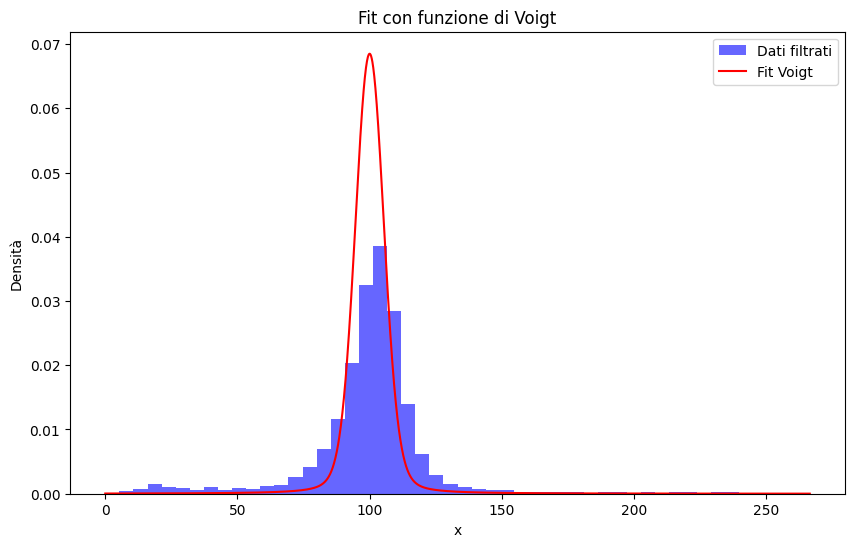

In [7]:
from turtle import color


plt.figure(figsize=(10, 6))
y_plot=[voigt(x, m_voigt.values["norm"], m_voigt.values["mu"], m_voigt.values["sigma"], m_voigt.values["gamma"]) for x in x_plot]
plt.hist(x_plot, bins=50, density=True, alpha=0.6, color='blue', label='Dati filtrati')
plt.plot(x_plot, y_plot, label='Fit Voigt', color='red')
plt.xlabel('x')
plt.ylabel('Densità')   
plt.title('Fit con funzione di Voigt')
plt.legend()
plt.show()

In [4]:
fit_MH100_values={}
fit_MH100_errors={}

fit_values={'MH100': fit_MH100_values,}
fit_errors={'MH100_errors': fit_MH100_errors}

for param in m_voigt.parameters:
    fit_MH100_values[param] = m_voigt.values[param]

for error in m_voigt.parameters:    #Qui non ho capito come fa a capire che deveestarre gli errori 
    fit_MH100_errors[error] = m_voigt.errors[error]

print(fit_MH100_values)
print(fit_MH100_errors)

import json
#QUi sono andato di metodo oragutang, ho deciso di voler fare 2 file separati peer errori e valori 
#Ho tenuto lo stesso quello con tutti i valori, casomai cambiassi idea

with open("fit_results.json", "r") as f:
    results=json.load(f)

with open("fit_values.json", "r") as g:
    values=json.load(g) 

with open("fit_errors.json", "r") as h:
    errors=json.load(h)


results["MH100"]=fit_MH100_values
results["MH100_errors"]=fit_MH100_errors

with open("fit_results.json", "w") as f:
    json.dump(results, f, indent=1)

values["MH100"]=fit_MH100_values
with open("fit_values.json", "w") as g:
    json.dump(values, g, indent=1)  

errors["MH100_errors"]=fit_MH100_errors
with open("fit_errors.json", "w") as h:
    json.dump(errors, h, indent=1)  


{'norm': 1.0, 'mu': 100.0, 'sigma': 5.0, 'gamma': 1.0}
{'norm': nan, 'mu': nan, 'sigma': nan, 'gamma': nan}
